In [1]:
import matplotlib.pyplot as plt
import os, duckdb
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, State, ctx
import dash_bootstrap_components as dbc
from dash_bootstrap_templates import ThemeSwitchAIO, load_figure_template

# Load The Data

In [2]:
cwd = os.getcwd()
parent = os.path.dirname(cwd)

over_world_dim = os.path.join(parent, 'data', 'signs_pretty_overworld.csv')
nether_dim = os.path.join(parent, 'data', 'signs_pretty_nether.csv')
end_dim = os.path.join(parent, 'data', 'signs_pretty_end.csv')

end_df = pd.read_csv(end_dim)
nether_df = pd.read_csv(nether_dim)
over_world_df = pd.read_csv(over_world_dim)

# Work on end visualization


### Grab all cody signs

In [3]:

filtered_end_df = end_df[end_df['plain_text'].str.contains('codysmile11|Codysmile11', na=False)]
filtered_end_df.tail()


,x,y,z,is_1.12.2,plain_text
96945,76151,67,-112115,0,codysmile11 Has Been Here :) 24 July 2024
96951,-75995,60,-25633,0,codysmile11 Has Been Here :) 25 Sep 2024
97632,25001,76,2,0,DouglasTheThird 09/10/2023 Fuck Codysmile11
98431,127580,55,0,1,codysmile11
98453,127779,55,-1,1,codysmile11


### Get the dates of all cody signs

In [4]:
filtered_end_df = filtered_end_df.copy()

dates = filtered_end_df['plain_text'].str.extract(
    r'(\d{1,2}\s+[A-Za-z]{3,9}\s+\d{4})',
    expand=False)

dates = dates.str.strip()

filtered_end_df['cody_sign_date'] = pd.to_datetime(
    dates,
    format='%d %b %Y',
    errors='coerce')

mask = filtered_end_df['cody_sign_date'].isna()

filtered_end_df.loc[mask, 'cody_sign_date'] = pd.to_datetime(
    dates[mask],
    format='%d %B %Y',
    errors='coerce')

filtered_end_df.head(20)

,x,y,z,is_1.12.2,plain_text,cody_sign_date
19,150,213,5,0,codysmile11 Has Been Here :) 24 July 2024,2024-07-24
22,151,211,1,0,codysmile11 Has Been Here :) 24 July 2024,2024-07-24
24,151,212,1,0,codysmile11 Has Been Here :) 24 July 2024,2024-07-24
25,87,165,-27,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
26,150,214,5,0,codysmile11 Has Been Here :) 24 July 2024,2024-07-24
30,87,170,-29,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
32,87,172,-30,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
38,87,173,-30,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
42,87,168,-28,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
50,87,169,-29,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25


### Sort by Date

In [5]:
sorted_end_df = filtered_end_df.sort_values(by=['cody_sign_date'], ascending=True)
sorted_end_df = sorted_end_df.dropna()
sorted_end_df.tail(20)

,x,y,z,is_1.12.2,plain_text,cody_sign_date
5187,418,3,1998,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5078,316,175,1997,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5238,395,162,2001,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5239,388,110,2010,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5242,396,161,2003,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5246,390,110,2011,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5247,399,161,2010,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5293,404,162,2012,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5248,395,162,2000,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5255,388,110,2013,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11


### Signs By Year Amount

cody_sign_date
2022.0       1
2023.0     391
2024.0    8000
2025.0     180
Name: cody_sign_date, dtype: int64
cody_sign_date
1.0       41
4.0      187
6.0      180
7.0     1757
8.0       13
9.0      804
10.0    5455
12.0     135
Name: cody_sign_date, dtype: int64


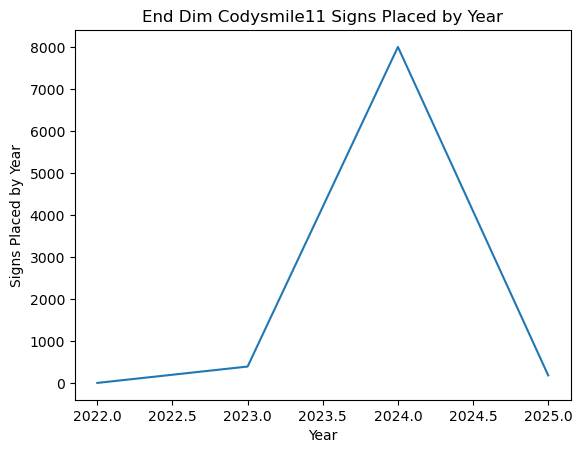

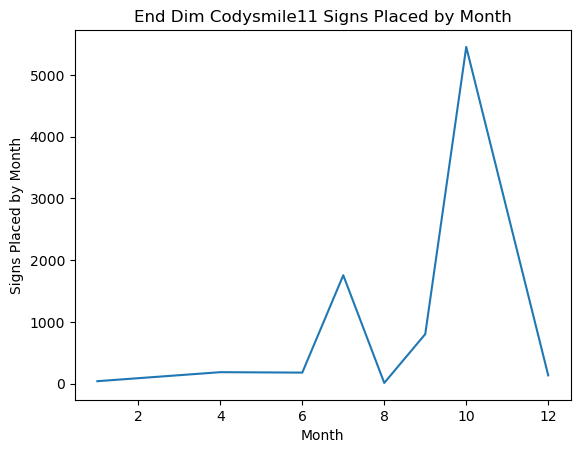

In [6]:
year_count_end = filtered_end_df.groupby(filtered_end_df['cody_sign_date'].dt.year)['cody_sign_date'].count()
print(year_count_end)

month_count_end = filtered_end_df.groupby(filtered_end_df['cody_sign_date'].dt.month)['cody_sign_date'].count()

print(month_count_end)

plt.plot(year_count_end)
plt.title("End Dim Codysmile11 Signs Placed by Year")
plt.xlabel("Year")
plt.ylabel("Signs Placed by Year")
plt.show()

plt.plot(month_count_end)
plt.title("End Dim Codysmile11 Signs Placed by Month")
plt.xlabel("Month")
plt.ylabel("Signs Placed by Month")
plt.show()
# http://127.0.0.1:8050/


# Work On Nether Visualizations

### Grab All Cody Signs

In [9]:
filtered_nether_df = nether_df[nether_df['plain_text'].str.contains('Codysmile11|Codysmile11', na=False)]
filtered_nether_df.head()

,x,y,z,is_1.12.2,plain_text
11856,-5001,120,-7976,0,Codysmile11 IS LAME ASF -NootNoottZ
46766,14570,121,4998,0,Fuck you Codysmile11 why so many fucking signs
48800,14908,120,3593,1,"""Codysmile11 blac k"" -Niet_Davy"
61715,18993,122,-5003,0,Codysmile11 is a fat stinky Nigger
81701,-19997,121,-39999,0,Fuck Codysmile11 Swimingfishtaco mfmfmmfmfakdj...


### Get all dates from the signs

In [14]:
filtered_nether_df = filtered_nether_df.copy()

dates = filtered_nether_df['plain_text'].str.extract(
    r'(\d{1,2}\s+[A-Za-z]{3,9}\s+\d{4})',
    expand=False)

dates = dates.str.strip()

filtered_nether_df['cody_sign_date'] = pd.to_datetime(
    dates,
    format='%d %b %Y',
    errors='coerce')

mask = filtered_nether_df['cody_sign_date'].isna()

filtered_nether_df.loc[mask, 'cody_sign_date'] = pd.to_datetime(
    dates[mask],
    format='%d %B %Y',
    errors='coerce')

filtered_nether_df.head(10)

,x,y,z,is_1.12.2,plain_text,cody_sign_date
11856,-5001,120,-7976,0,Codysmile11 IS LAME ASF -NootNoottZ,NaT
46766,14570,121,4998,0,Fuck you Codysmile11 why so many fucking signs,NaT
48800,14908,120,3593,1,"""Codysmile11 blac k"" -Niet_Davy",NaT
61715,18993,122,-5003,0,Codysmile11 is a fat stinky Nigger,NaT
81701,-19997,121,-39999,0,Fuck Codysmile11 Swimingfishtaco mfmfmmfmfakdj...,NaT
86105,4998,121,-32721,0,Codysmile11 took a big black cock here,NaT
92207,-20003,121,-35003,0,Swimingfishtaco Fuck Codysmile11,NaT
94612,15000,120,37279,0,Codysmile11 smells like rotten fish,NaT
163529,1859,85,2823,0,Codysmile11 was here anklebiteryt was also here,NaT


### Sort The Dates

In [12]:
sorted_nether_df = filtered_nether_df.sort_values(by=['cody_sign_date'], ascending=True)
sorted_nether_df = sorted_nether_df.dropna()
sorted_nether_df.tail(20)

,x,y,z,is_1.12.2,plain_text,cody_sign_date
